In [9]:
# =====================================================================
# PHASE 1: NLP INITIALIZATION & LIBRARIES
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set graphic styling parameters for professional visualization
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (8, 5)
print("Setup Complete: Required analytics libraries imported successfully.")


Setup Complete: Required analytics libraries imported successfully.


In [ ]:
# =====================================================================
# PHASE 2: DATA LOADING & PREPROCESSING (PLAY STORE USER REVIEWS)
# =====================================================================
# Load  Play Store csv file
df_sentiment = pd.read_csv('user_reviews.csv')

# the exact columns present in  user_review.csv file
TEXT_COLUMN = 'Translated_Review'
TARGET_COLUMN = 'Sentiment'

# Clean data: Drop missing rows to keep our strings intact
df_sentiment = df_sentiment.dropna(subset=[TEXT_COLUMN, TARGET_COLUMN])

# Normalize text formatting: Convert to lowercase and strip leading/trailing spaces
df_sentiment[TEXT_COLUMN] = df_sentiment[TEXT_COLUMN].astype(str).str.lower().str.strip()

print(f"Data ingested. Pipeline verified with {df_sentiment.shape} rows.")
print("\n--- Target Sentiment Class Distribution ---")
print(df_sentiment[TARGET_COLUMN].value_counts())


Data ingested. Pipeline verified with (37427, 5) rows.

--- Target Sentiment Class Distribution ---
Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


In [11]:
# =====================================================================
# PHASE 3: FEATURE ENGINEERING & DATA SPLITTING
# =====================================================================
X = df_sentiment[TEXT_COLUMN]
y = df_sentiment[TARGET_COLUMN]

# Split data into training (80%) and testing (20%) sets using stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize TF-IDF Vectorizer to extract top 5000 text features and remove English stopwords
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

# Transform raw human language text strings into mathematical numeric matrices
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Feature engineering finalized. Text matrices constructed.")
print(f"Training Matrix Shape: {X_train_tfidf.shape} | Testing Matrix Shape: {X_test_tfidf.shape}")


Feature engineering finalized. Text matrices constructed.
Training Matrix Shape: (29941, 5000) | Testing Matrix Shape: (7486, 5000)


In [12]:
# =====================================================================
# PHASE 4: MACHINE LEARNING MODEL TRAINING & METRIC EVALUATION
# =====================================================================
# Initialize and train the Multinomial Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Generate sentiment predictions on unseen test records
y_pred = model.predict(X_test_tfidf)

# Calculate and print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model training concluded. Accuracy metric computed at: {accuracy * 100:.2f}%")
print("📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred))


Model training concluded. Accuracy metric computed at: 73.56%
📋 Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.42      0.56      1654
     Neutral       0.83      0.10      0.18      1032
    Positive       0.72      0.98      0.83      4800

    accuracy                           0.74      7486
   macro avg       0.80      0.50      0.52      7486
weighted avg       0.76      0.74      0.68      7486



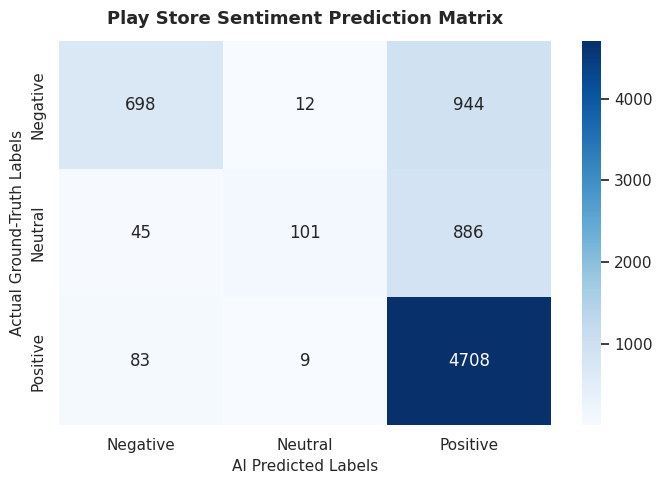

Evaluation of visullization : heatmap rendered!


In [16]:
# =====================================================================
# PHASE 5: SENTIMENT VISUALIZATION
# =====================================================================
# Generate the analytical Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = sorted(df_sentiment[TARGET_COLUMN].unique())

# Build the professional heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Play Store Sentiment Prediction Matrix', fontsize=13, weight='bold', pad=12)
plt.xlabel('AI Predicted Labels', fontsize=11)
plt.ylabel('Actual Ground-Truth Labels', fontsize=11)
plt.tight_layout()
plt.show()
print("Evaluation of visullization : heatmap rendered!")
